# CNN Predict — CESM2-LE JJA SST → September Slowdown

Loads **precomputed CNN predictions** and reproduces the same figures as `cnn_train.ipynb` **without re-training or re-running inference**. Also generates composite maps of the SST input and LRP attributions for TP / FP / TN / FN scenarios.

**Prerequisites**
- `python scripts/04_cesm2le_cnn_train.py` — trains models and saves JSON histories
- `python scripts/05_cesm2le_lrp.py` — computes and saves LRP attributions
- `python scripts/06_cnn_predict_cesm2le.py` — precomputes and saves predictions

**Set `N_SPLITS` and `N_SEEDS` to match the values used during training, then Run All.**

In [1]:
import sys
import json
from pathlib import Path

import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.metrics import (
    precision_recall_curve, confusion_matrix, ConfusionMatrixDisplay
)
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cmocean

PROJECT_ROOT = Path('..').resolve()
sys.path.insert(0, str(PROJECT_ROOT))

from configs import paths
from src.cnn.splits import load_tvt_split
from src.cnn.model  import METRIC_NAMES

# ── Publication figure defaults ───────────────────────────────────────────────
plt.rcParams.update({
    'font.size': 14*5,
    'axes.titlesize': 16*5,
    'axes.labelsize': 14*5,
    'xtick.labelsize': 12*5,
    'ytick.labelsize': 12*5,
    'legend.fontsize': 12*5,
})

2026-05-02 12:00:21.670044: I tensorflow/core/util/port.cc:111] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-05-02 12:00:21.696383: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2026-05-02 12:00:21.839048: E tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:9342] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-05-02 12:00:21.839089: E tensorflow/compiler/xla/stream_executor/cuda/cuda_fft.cc:609] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-05-02 12:00:21.839928: E tensorflow/compiler/xla/stream_executor/cuda/cuda_blas.cc:1518] Unable to register cuBLAS factory: Attempting to regi

## Config
Must match the values used in `cnn_train.ipynb` (or `scripts/04_cesm2le_cnn_train.py`).

In [2]:
# ── How many splits / seeds were trained ─────────────────────────────────────
N_SPLITS  = 9          # max 9
N_SEEDS   = 5          # random seeds per split
BASE_SEED = 42

# ── Dataset ───────────────────────────────────────────────────────────────────
BLOCK_SIZE = 10        # ensemble members per TVT block
START_YEAR = 1990      # first year in the loaded splits

METRICS_DIR     = paths.RESULTS_DIR / 'metrics'
PREDICTIONS_DIR = paths.RESULTS_DIR / 'predictions' / 'cesm2le'

## Load loop
Loads **metrics** from all splits, but only loads predictions, histories,
LRP attributions, and SST arrays for **one** split × seed (`LOAD_SPLIT`, `LOAD_SEED`).

> **Note:** Composite maps requiring all models have been moved to
> `F2-3_FS8-S9_composite_pdf.ipynb`.


In [3]:
# Load only ONE model/prediction set (split 0, seed 0) for visualisation.
# Metrics are still loaded from ALL splits for the cross-split evaluation plot.
#
# results[split_idx] = {
#   'ds_metrics':    xr.Dataset       — loaded for ALL splits
# }
# For the single selected split/seed we also store:
#   'histories':     list[dict]        — one entry (the selected seed)
#   'y_scores_runs': list[dict]        — one entry
#   'y_true':        dict              — keys: train/val/test
#   'lrp_data':      list[dict|None]   — one entry
#   'sst_tr':        np.ndarray        — (n_tr, nx, ny)
#   'lat':           np.ndarray
#   'lon':           np.ndarray

LOAD_SPLIT = 0   # only load predictions/LRP for this split
LOAD_SEED  = 0   # only load predictions/LRP for this seed

results = {}

for split_idx in range(N_SPLITS):
    print(f'\n{"─"*60}')
    print(f'Split {split_idx}')
    print(f'{"─"*60}')

    # ── Metrics dataset (loaded for EVERY split) ───────────────────────────
    metrics_p = paths.metrics_path(split_idx)
    if not metrics_p.exists():
        raise FileNotFoundError(
            f'Metrics not found: {metrics_p}\n'
            f'Run scripts/04_cesm2le_cnn_train.py first.'
        )
    ds_metrics = xr.open_dataset(metrics_p)
    results[split_idx] = {'ds_metrics': ds_metrics}
    print(f'  metrics ✓')

    # ── Only load full data for the selected split ────────────────────────
    if split_idx != LOAD_SPLIT:
        continue

    # TVT split (for labels and SST arrays)
    split_path = paths.tvt_split_path(split_idx)
    if not split_path.exists():
        raise FileNotFoundError(
            f'TVT split not found: {split_path}\n'
            f'Run scripts/03_cesm2le_tvt_splits.py first.'
        )
    split = load_tvt_split(split_path)

    y_tr = split['slow_tr']
    y_va = split['slow_va']
    y_te = split['slow_te']
    y_true = {'train': y_tr, 'val': y_va, 'test': y_te}

    print(f'  Train: ({len(y_tr)},)  prevalence={y_tr.mean():.3f}')
    print(f'  Val  : ({len(y_va)},)  prevalence={y_va.mean():.3f}')
    print(f'  Test : ({len(y_te)},)  prevalence={y_te.mean():.3f}')

    run_idx = LOAD_SEED
    print(f'  seed {BASE_SEED + run_idx}: ', end='', flush=True)

    # ── Load precomputed predictions ──────────────────────────────────
    pred_path = PREDICTIONS_DIR / f'cnn_prediction_cesm2le_M{split_idx}_{run_idx}.nc'
    if not pred_path.exists():
        raise FileNotFoundError(
            f'Prediction file not found: {pred_path}\n'
            f'Run scripts/06_cnn_predict_cesm2le.py first.'
        )
    with xr.open_dataset(pred_path) as ds_pred:
        y_scores_runs = [{
            'train': ds_pred['y_prob_train'].values,
            'val':   ds_pred['y_prob_val'].values,
            'test':  ds_pred['y_prob_test'].values,
        }]
    print('predictions ✓', end='  ', flush=True)

    # ── Training history ──────────────────────────────────────────────
    hist_path = paths.LOGS_DIR / f'history_split{split_idx}_run{run_idx}.json'
    if hist_path.exists():
        with open(hist_path) as f:
            histories = [json.load(f)]
    else:
        histories = [None]
        print(f'(history not found: {hist_path})', end='  ')
    print('history ✓', end='  ', flush=True)

    # ── LRP attributions ──────────────────────────────────────────────
    lrp_path = paths.attribution_path(split_idx, run_idx)
    lrp_data = []
    lat_shared = None
    lon_shared = None
    if lrp_path.exists():
        lrp_ds   = xr.open_dataset(lrp_path)
        lrp_raw  = lrp_ds['lrp_attributions'].values
        lat_1d   = lrp_ds['lat'].values
        lon_1d   = lrp_ds['lon'].values
        lrp_ds.close()
        lrp_flat = lrp_raw.reshape(-1, lrp_raw.shape[2], lrp_raw.shape[3])
        lrp_data = [{'lrp_flat': lrp_flat}]
        lat_shared = lat_1d
        lon_shared = lon_1d
        print('LRP ✓')
    else:
        lrp_data = [None]
        print(f'(LRP not found: {lrp_path})')

    results[split_idx].update({
        'histories':     histories,
        'y_scores_runs': y_scores_runs,
        'y_true':        y_true,
        'lrp_data':      lrp_data,
        'sst_tr':        split['sst_tr'],
        'lat':           lat_shared,
        'lon':           lon_shared,
    })

print('\nLoading complete.')



────────────────────────────────────────────────────────────
Split 0
────────────────────────────────────────────────────────────
  metrics ✓
  Train: (4080,)  prevalence=0.275
  Val  : (510,)  prevalence=0.310
  Test : (510,)  prevalence=0.267
  seed 42: predictions ✓  (history not found: /mnt/tank/Oceanography/data/OGCM/LLC/Fronts/lohoff/arcticWatch/results/logs/history_split0_run0.json)  history ✓  LRP ✓

────────────────────────────────────────────────────────────
Split 1
────────────────────────────────────────────────────────────
  metrics ✓

────────────────────────────────────────────────────────────
Split 2
────────────────────────────────────────────────────────────
  metrics ✓

────────────────────────────────────────────────────────────
Split 3
────────────────────────────────────────────────────────────
  metrics ✓

────────────────────────────────────────────────────────────
Split 4
────────────────────────────────────────────────────────────
  metrics ✓

───────────────

---
## Visualization

**Plots 0–2 and 4** show results for a single split × seed — set `PLOT_SPLIT` and `PLOT_SEED` below.  
**Plot 3** aggregates across all loaded splits and seeds.

In [4]:
PLOT_SPLIT = LOAD_SPLIT
PLOT_SEED  = 0    # index within the loaded seeds (always 0 since we load one)

# Convenience references
res      = results[PLOT_SPLIT]
hist     = res['histories'][PLOT_SEED]    # dict loaded from JSON (or None)
y_scores = res['y_scores_runs'][PLOT_SEED]
y_true   = res['y_true']


### 0 — Learning curves

In [5]:
if hist is None:
    print(f'No history file for split {PLOT_SPLIT}, seed {PLOT_SEED}.')
else:
    epochs = np.arange(1, len(hist['loss']) + 1)

    fig, ax = plt.subplots(figsize=(7, 4))
    ax.plot(epochs, hist['loss'],     color='steelblue', linewidth=2.0, label='train loss')
    ax.plot(epochs, hist['val_loss'], color='steelblue', linewidth=2.0, label='val loss',
            linestyle='--')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.set_title('(a)')
    ax.legend()
    plt.tight_layout()
    plt.show()

No history file for split 0, seed 0.


### 1 — Precision–Recall curve & threshold selection

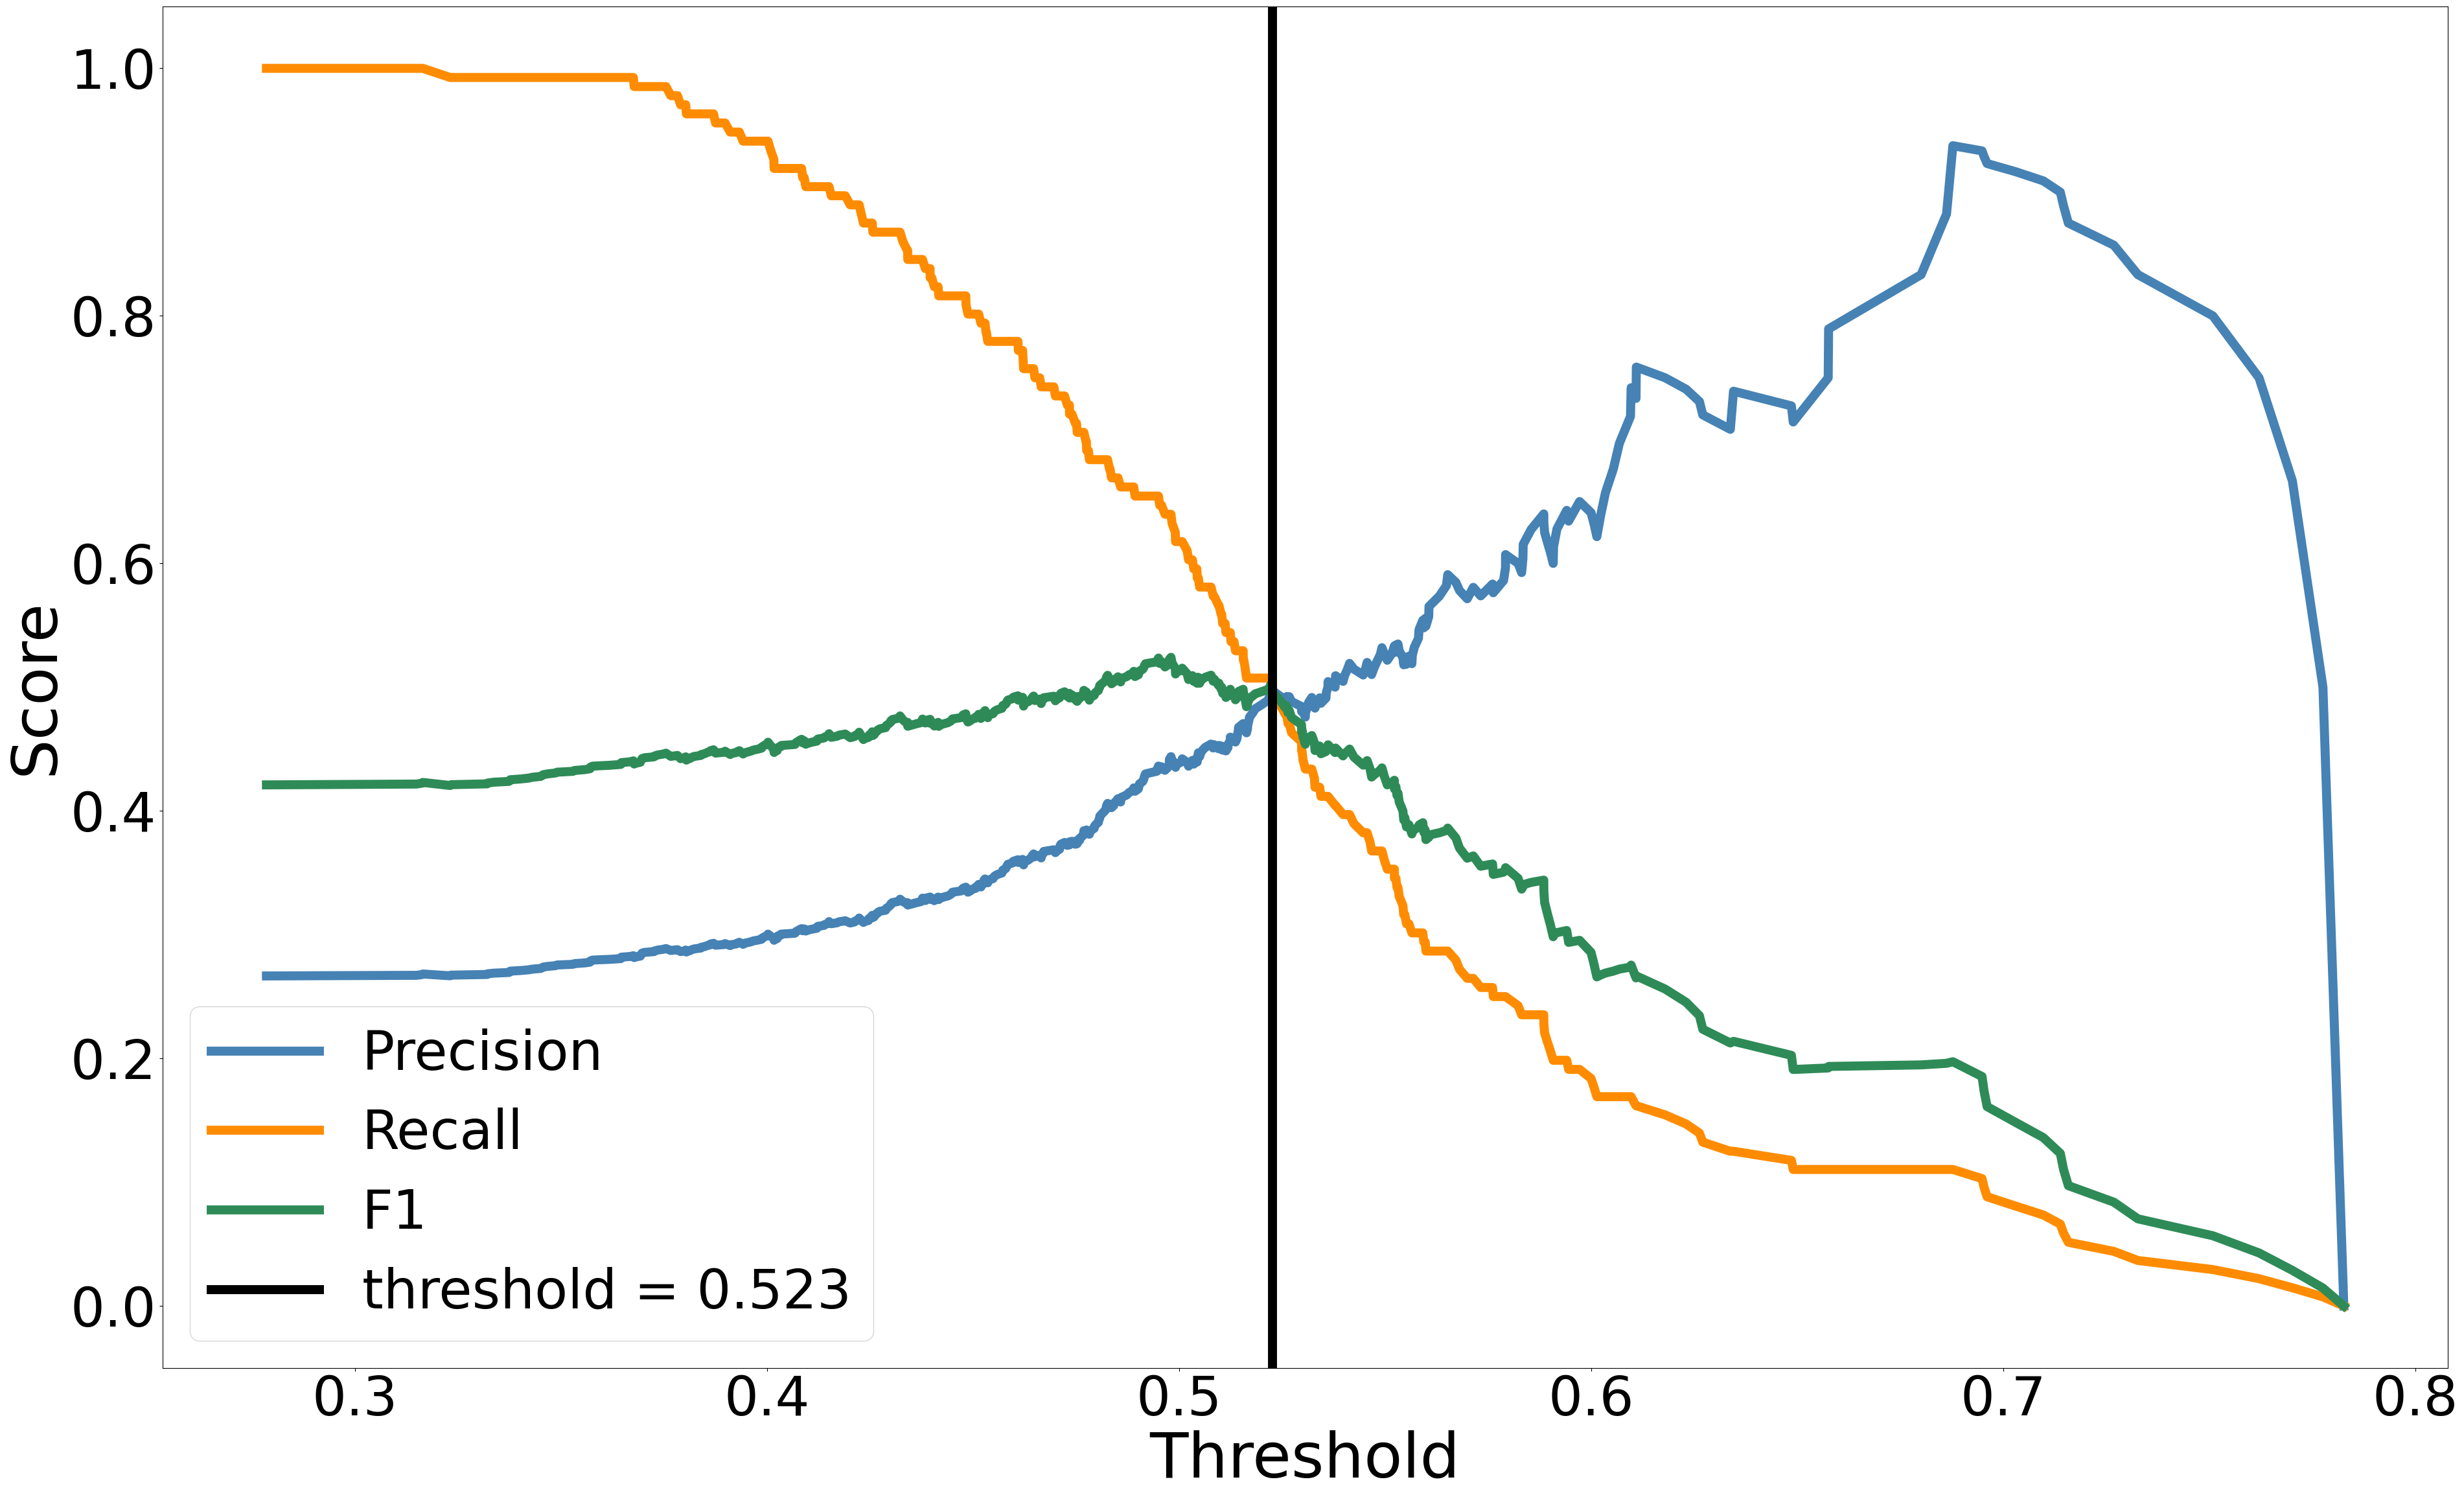

Selected threshold: 0.5226  (Precision=0.493, Recall=0.493)


In [6]:
y_s = y_scores['test']
y_t = y_true['test']

precision, recall, thresholds = precision_recall_curve(y_t, y_s)

# F1 at each threshold
f1_scores = 2 * precision[:-1] * recall[:-1] / (precision[:-1] + recall[:-1] + 1e-9)

# Threshold at precision–recall intersection (same rule as compute_metrics)
best_idx = np.argmin(np.abs(precision[:-1] - recall[:-1]))
best_thr = thresholds[best_idx]

fig, ax = plt.subplots(figsize=(8*5, 5*5))
ax.plot(thresholds, precision[:-1], label='Precision', color='steelblue', linewidth=2.0*5)
ax.plot(thresholds, recall[:-1],    label='Recall',    color='darkorange', linewidth=2.0*5)
ax.plot(thresholds, f1_scores,      label='F1',        color='seagreen', linewidth=2.0*5)
ax.axvline(best_thr, color='black', linewidth=2*5, label=f'threshold = {best_thr:.3f}')
ax.set_xlabel('Threshold')
ax.set_ylabel('Score')
#ax.set_title('(a)')
ax.legend()
plt.tight_layout()
plt.show()

print(f'Selected threshold: {best_thr:.4f}  '
      f'(Precision={precision[best_idx]:.3f}, Recall={recall[best_idx]:.3f})')

### 2 — Confusion matrices (train + test)

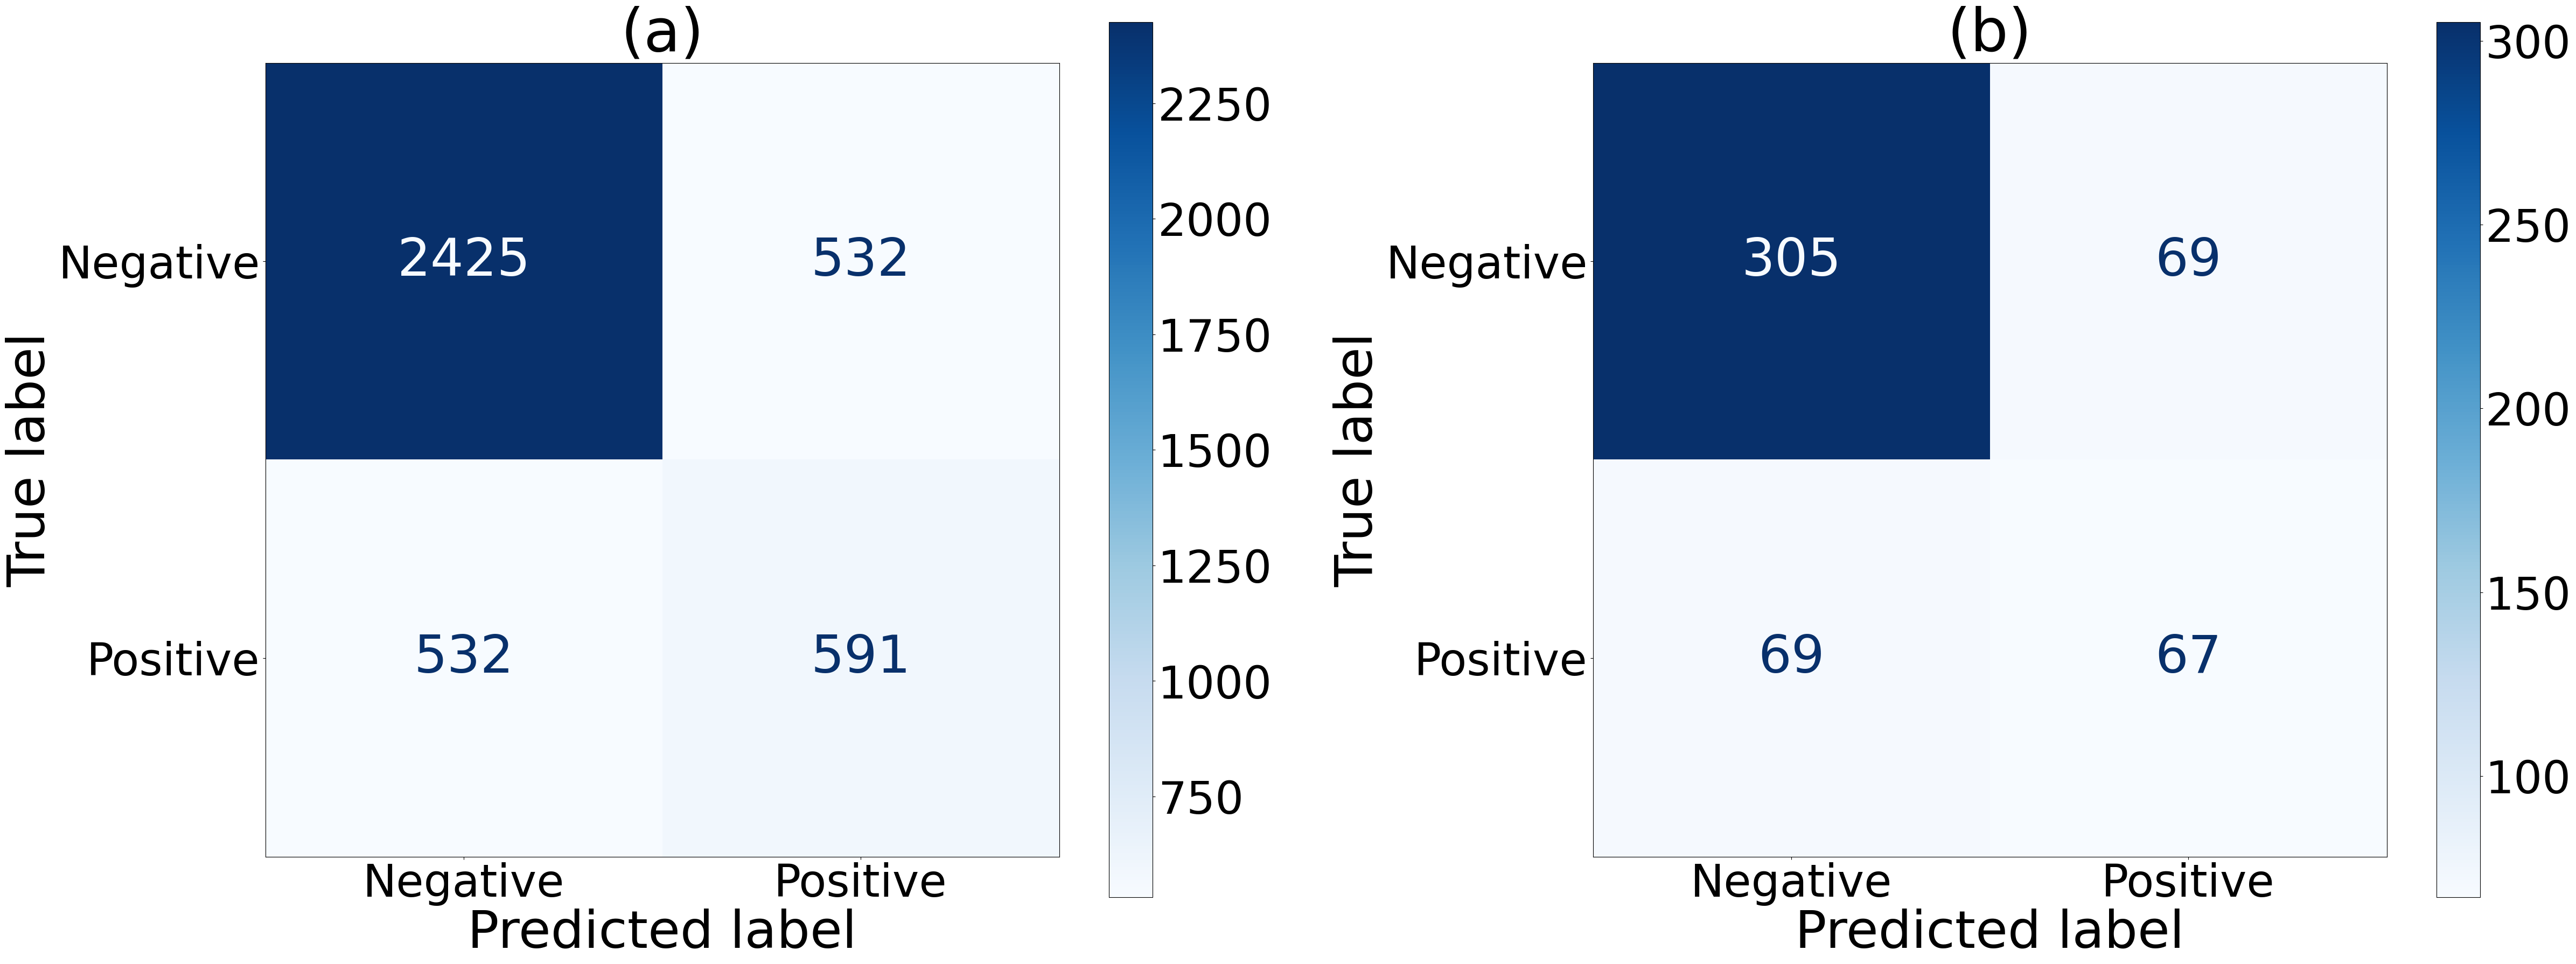

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(10*5, 4*5))

for idx, (ax, split_name) in enumerate(zip(axes, ['train', 'test'])):
    yt = y_true[split_name]
    ys = y_scores[split_name]

    prec, rec, thr = precision_recall_curve(yt, ys)
    if thr.size > 0:
        thr_best = thr[np.argmin(np.abs(prec[:-1] - rec[:-1]))]
    else:
        thr_best = 0.5

    y_pred = (ys >= thr_best).astype(int)
    cm     = confusion_matrix(yt, y_pred)

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=['Negative', 'Positive']
    )
    disp.plot(ax=ax, colorbar=True, cmap='Blues')
    label = chr(ord('a') + idx)
    ax.set_title(f'({label})')

plt.tight_layout()
plt.show()

### 3 — Evaluation metrics across all seeds & splits
Mean value per metric on the test split, with individual seed/split values overlaid.

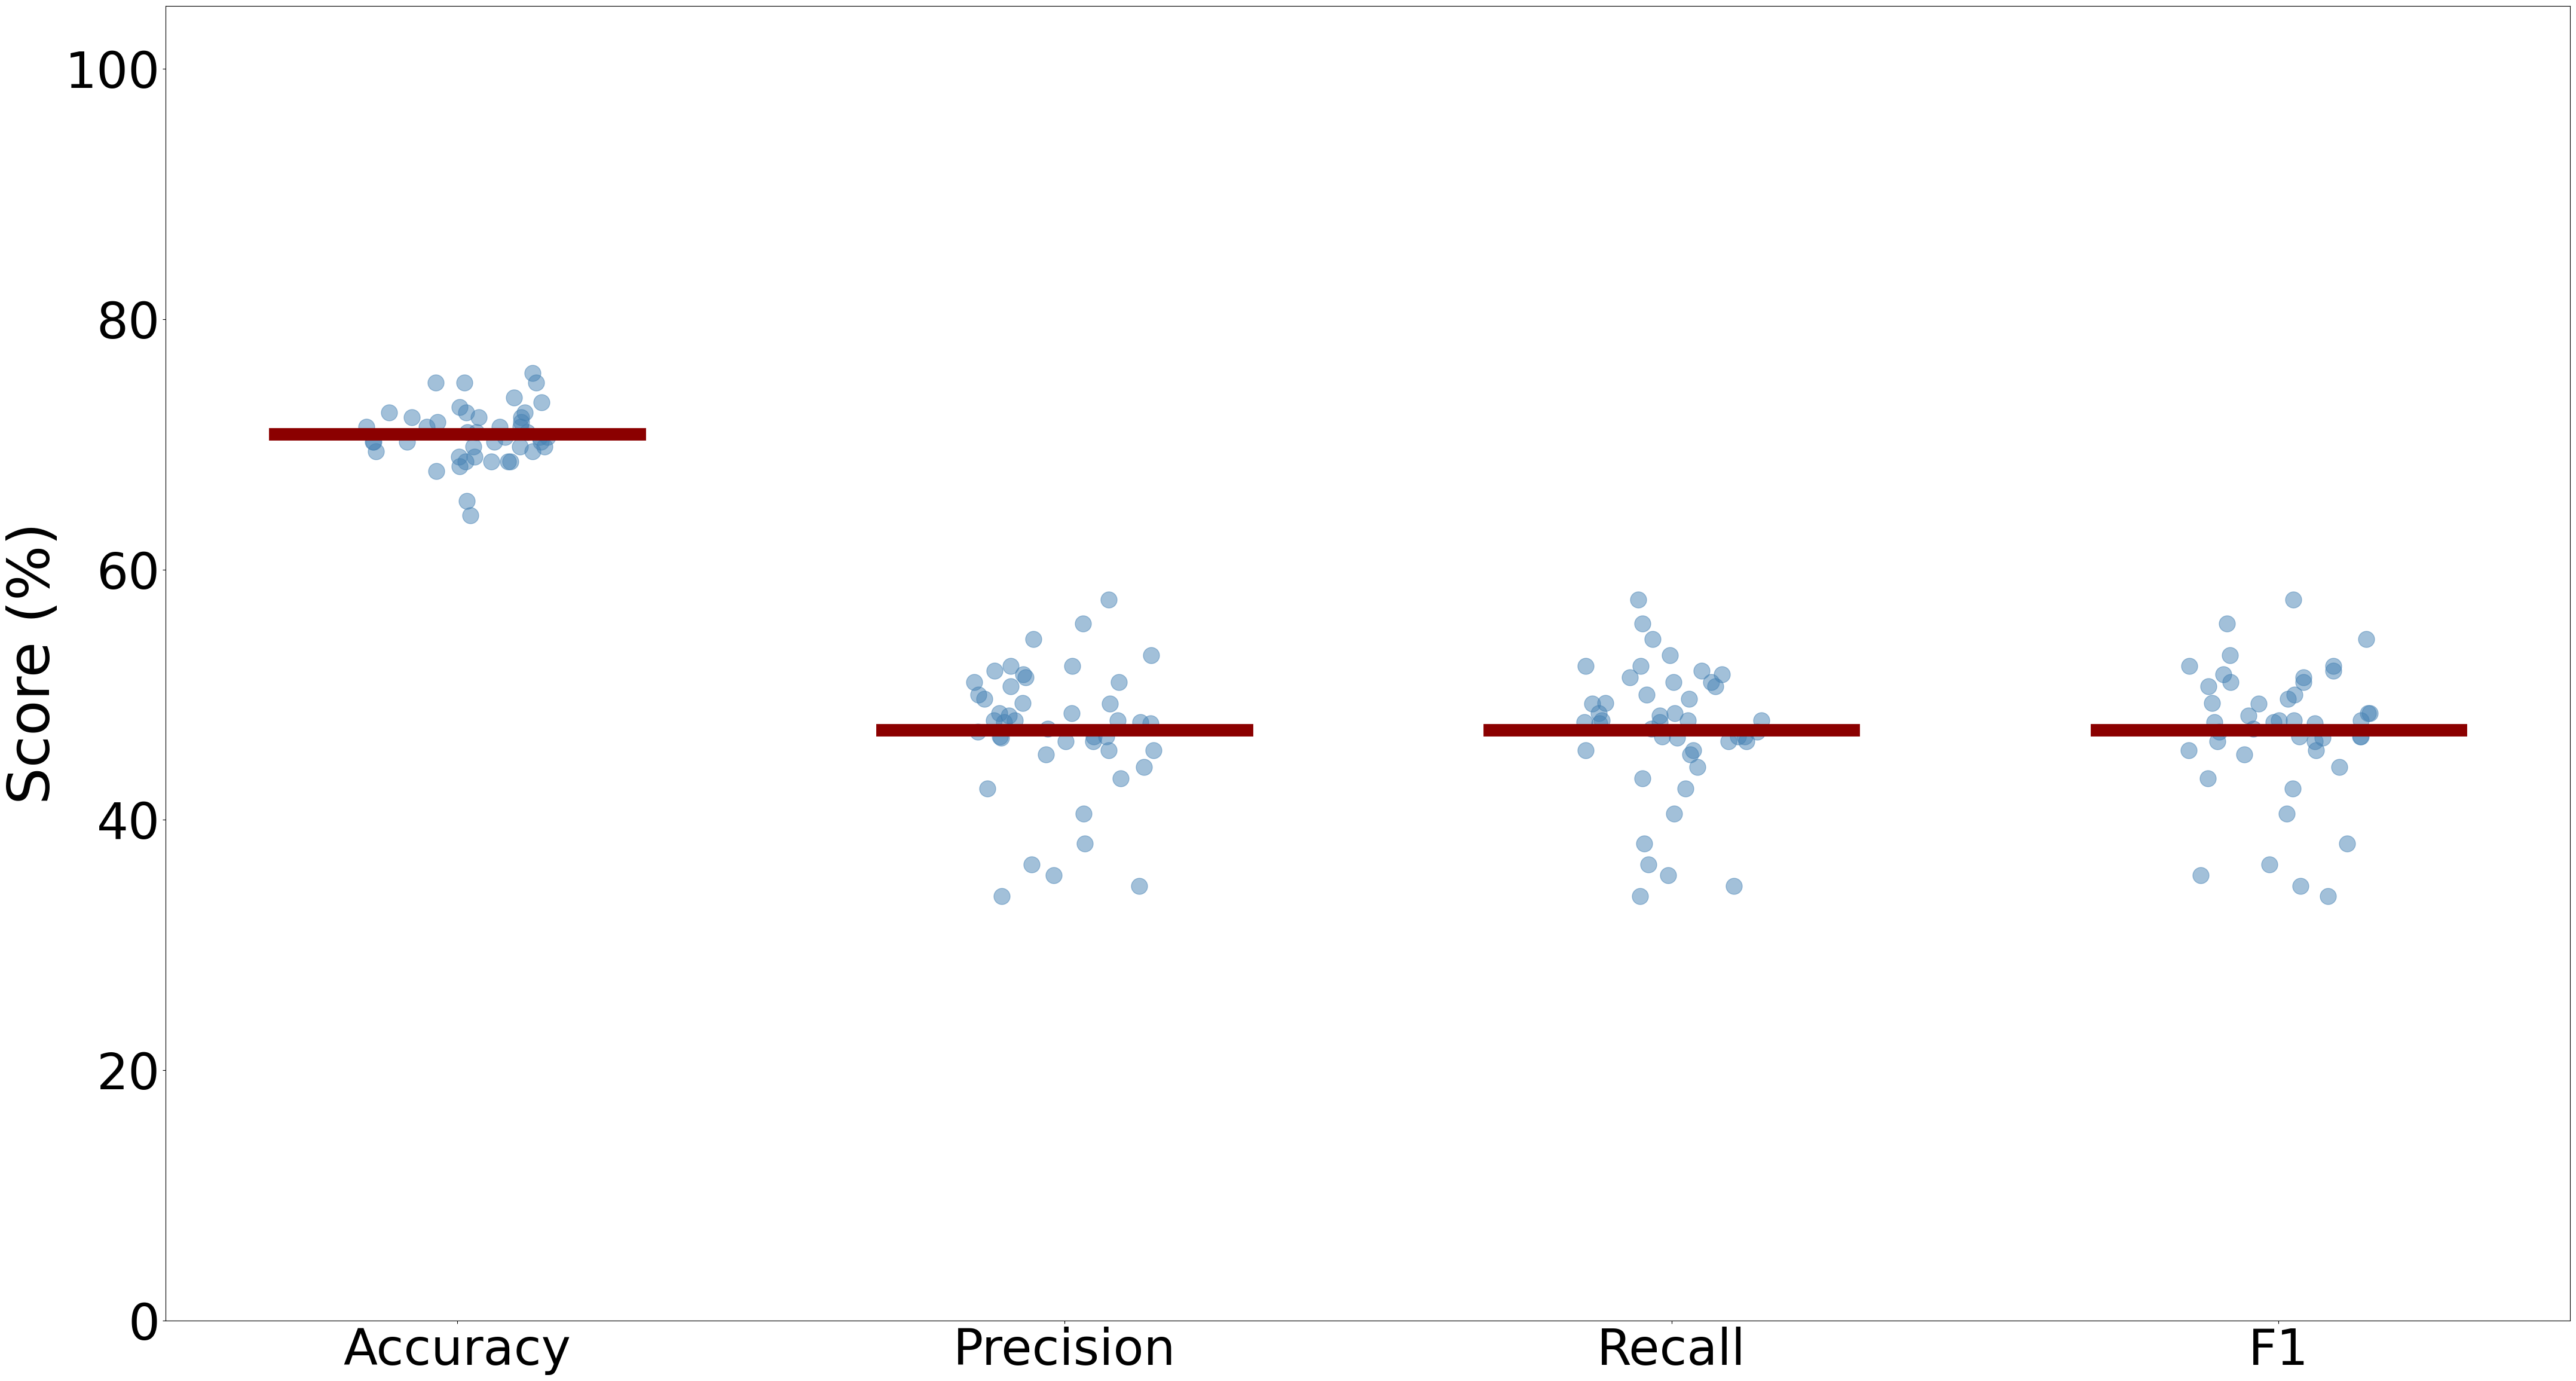

Mean scores:
  Accuracy: 70.8%
  Precision: 47.2%
  Recall: 47.2%
  F1: 47.2%
Median scores:
  Accuracy: 70.6%
  Precision: 47.8%
  Recall: 47.8%
  F1: 47.8%


In [8]:
all_vals = []
for sidx in range(N_SPLITS):
    ds = results[sidx]['ds_metrics']
    all_vals.append(ds['metric_value'].sel(split='test').values)  # (n_metrics, n_seeds)

all_vals = np.stack(all_vals, axis=0)               # (n_splits, n_metrics, n_seeds)
all_vals = all_vals.transpose(1, 0, 2)              # (n_metrics, n_splits, n_seeds)

DISPLAY_METRICS = ['Accuracy', 'Precision', 'Recall', 'F1'] #, 'AUPRC', 'AUROC', 'MCC']
display_idx     = [METRIC_NAMES.index(m) for m in DISPLAY_METRICS]

vals_display = all_vals[display_idx, :, :]
vals_flat    = vals_display.reshape(len(DISPLAY_METRICS), -1)
means        = np.nanmean(vals_flat, axis=1)
medians      = np.nanmedian(vals_flat, axis=1)

fig, ax = plt.subplots(figsize=(9*5, 5*5))

for i, (m, mean_val) in enumerate(zip(DISPLAY_METRICS, means)):
    jitter = np.random.uniform(-0.15, 0.15, size=vals_flat.shape[1])
    ax.scatter(
        np.full(vals_flat.shape[1], i) + jitter,
        vals_flat[i],
        color='steelblue', alpha=0.5, s=25*15, zorder=2
    )
    ax.plot([i - 0.3, i + 0.3], [mean_val, mean_val],
            color='darkred', linewidth=3.0*5, zorder=3)

ax.set_xticks(range(len(DISPLAY_METRICS)))
ax.set_xticklabels(DISPLAY_METRICS)
ax.set_ylabel('Score (%)')
#ax.set_title('(a)')
ax.set_ylim(0, 1.05)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x*100:.0f}'))
plt.tight_layout()
plt.show()

print('Mean scores:')
for m, mean_val in zip(DISPLAY_METRICS, means):
    print(f'  {m}: {mean_val*100:.1f}%')

print('Median scores:')
for m, median_val in zip(DISPLAY_METRICS, medians):
    print(f'  {m}: {median_val*100:.1f}%')

### 4 — Slowdown time series per ensemble member
Shows actual slowdowns (gray), correct predictions (green), and incorrect predictions (red) for each test-block member.

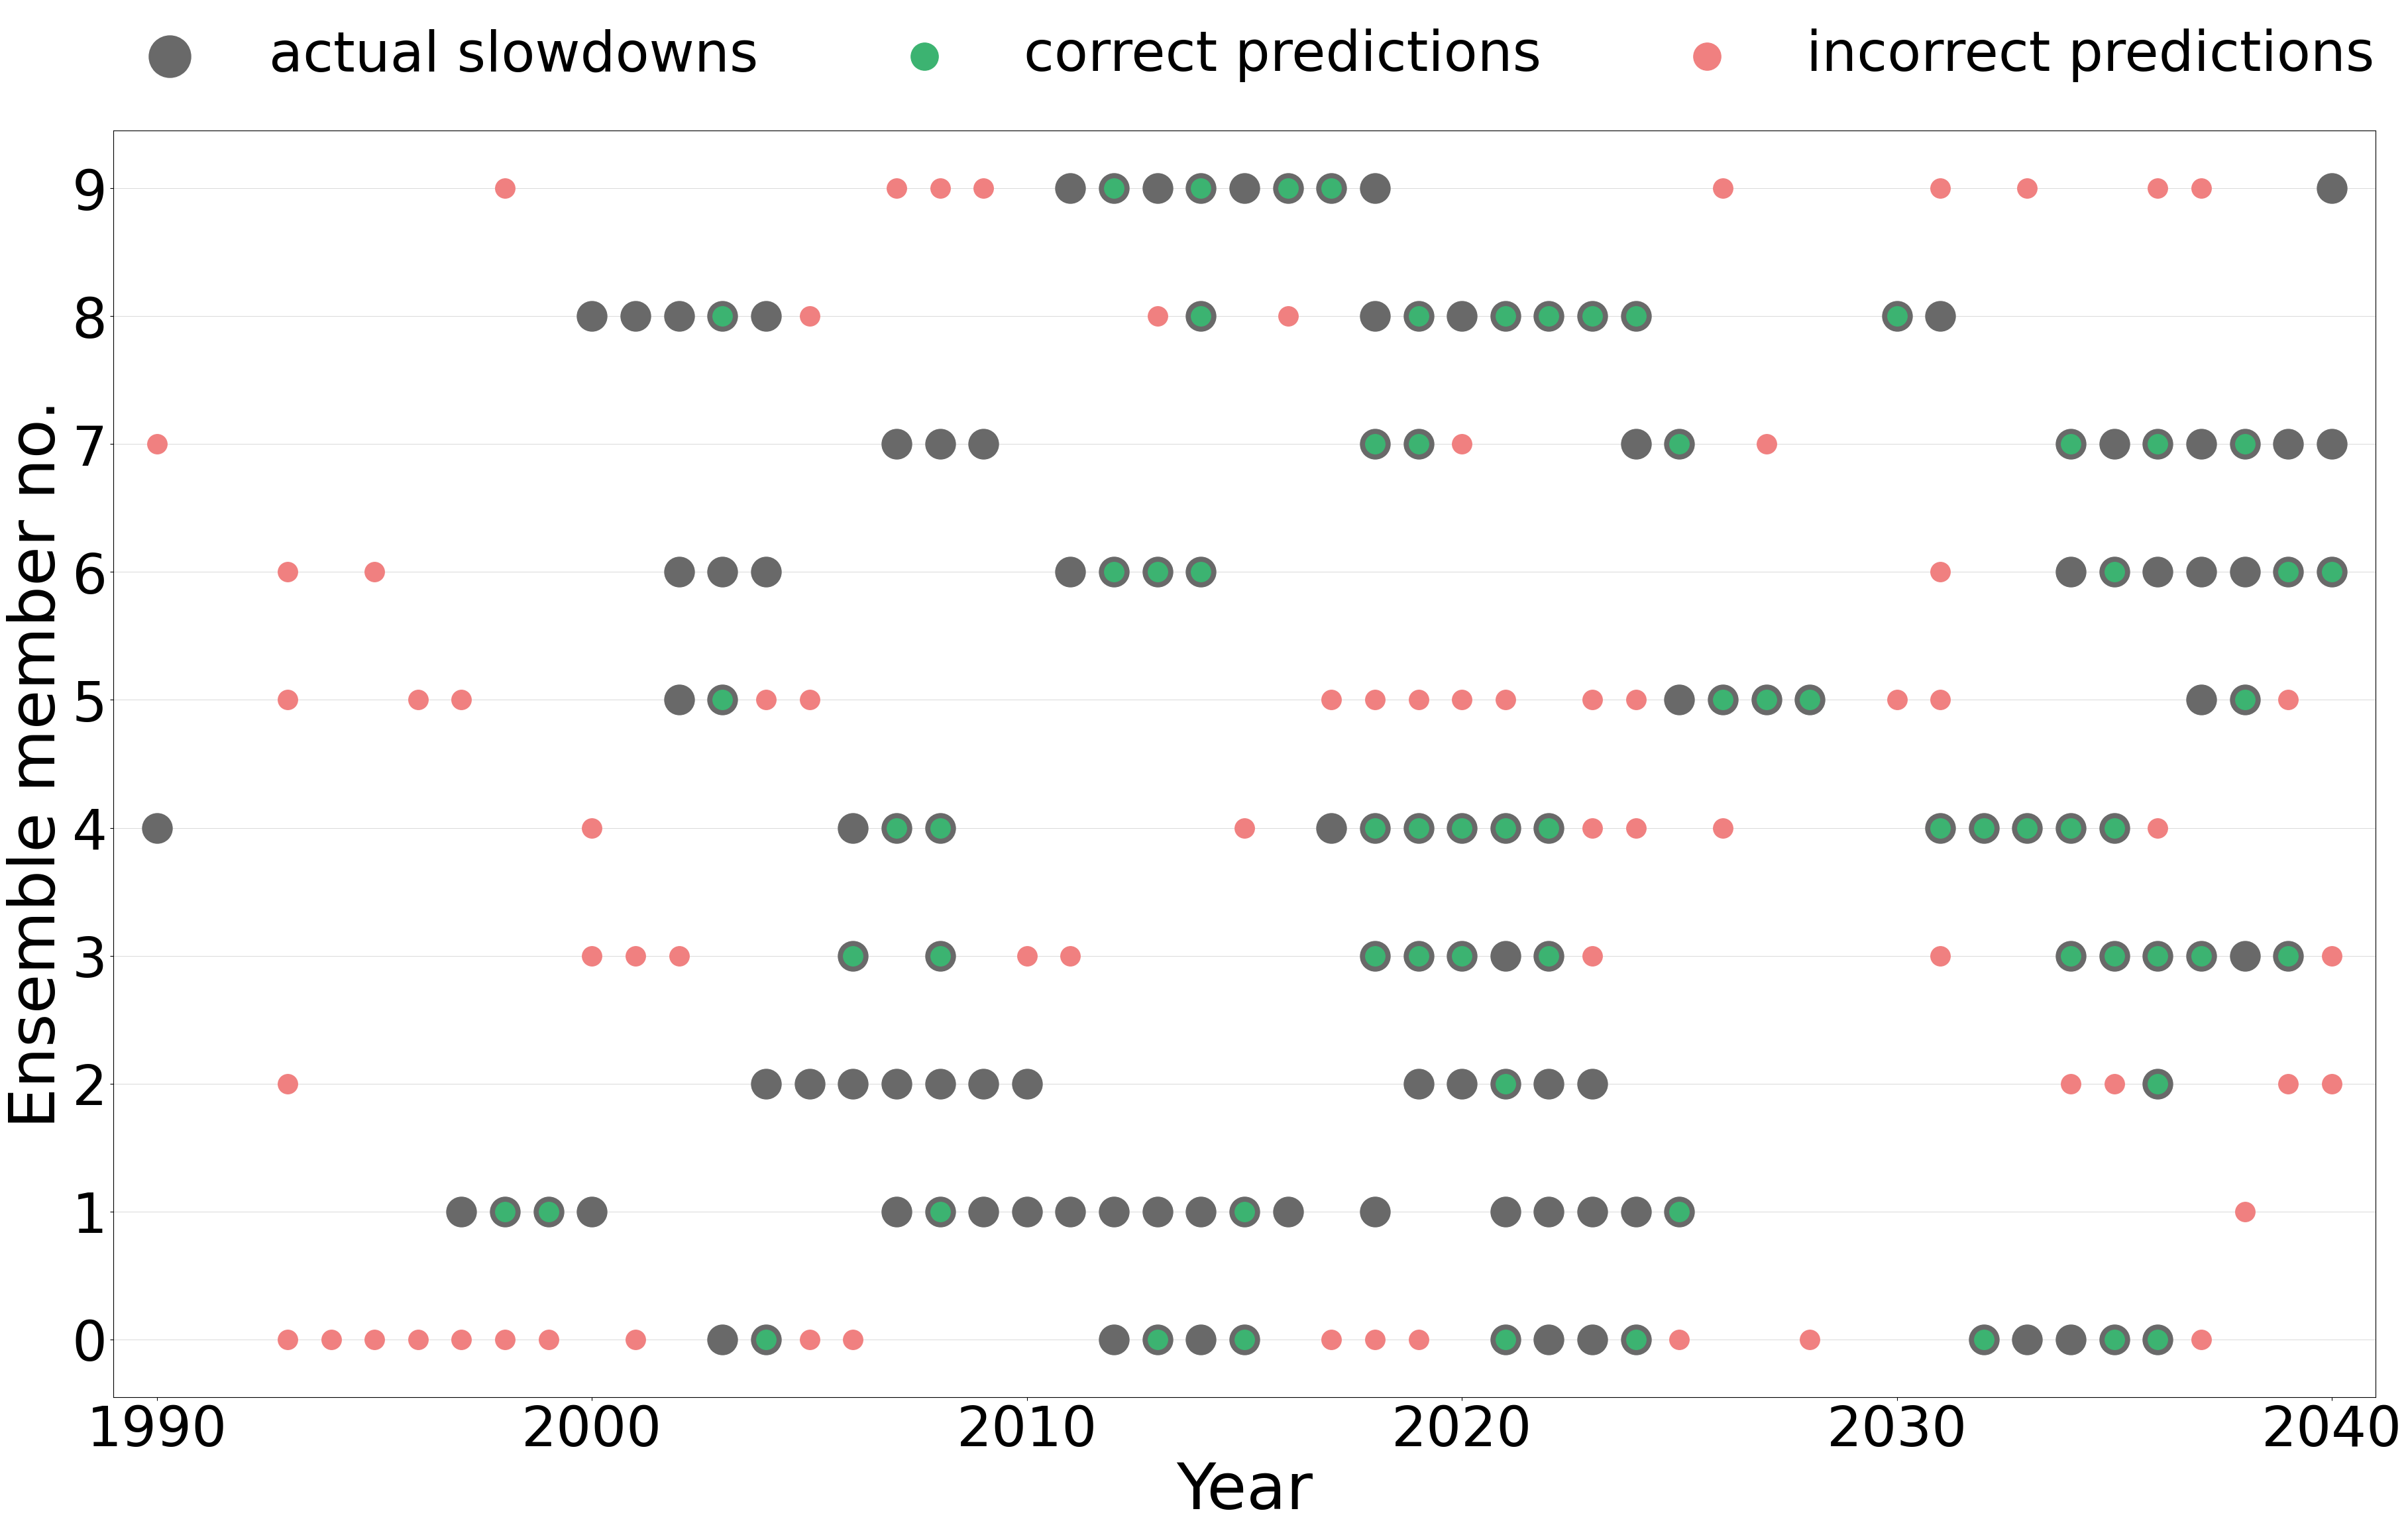

In [13]:
yt = y_true['test']
ys = y_scores['test']

prec, rec, thr = precision_recall_curve(yt, ys)
thr_best = thr[np.argmin(np.abs(prec[:-1] - rec[:-1]))] if thr.size > 0 else 0.5
y_pred   = (ys >= thr_best).astype(int)

nyears   = yt.shape[0] // BLOCK_SIZE
years    = np.arange(START_YEAR, START_YEAR + nyears)
yt_2d    = yt.reshape(BLOCK_SIZE, nyears)
ypred_2d = y_pred.reshape(BLOCK_SIZE, nyears)

test_block_start = PLOT_SPLIT * BLOCK_SIZE
member_labels    = np.arange(test_block_start, test_block_start + BLOCK_SIZE)

fig, ax = plt.subplots(figsize=(8*5, 5*5))

for m_idx, m_label in enumerate(member_labels):
    actual    = yt_2d[m_idx]
    predicted = ypred_2d[m_idx]

    ax.axhline(m_label, color='lightgray', linewidth=0.6, zorder=0)

    actual_yrs = years[actual == 1]
    ax.scatter(actual_yrs, np.full_like(actual_yrs, m_label, dtype=float),
               color='dimgray', s=70*15, zorder=2,
               label='actual slowdowns' if m_idx == 0 else '')

    tp_yrs = years[(predicted == 1) & (actual == 1)]
    ax.scatter(tp_yrs, np.full_like(tp_yrs, m_label, dtype=float),
               color='mediumseagreen', s=30*15, zorder=3,
               label='correct predictions' if m_idx == 0 else '')

    err_yrs = years[(predicted == 1) & (actual == 0)]
    ax.scatter(err_yrs, np.full_like(err_yrs, m_label, dtype=float),
               color='lightcoral', s=30*15  , zorder=3,
               label='incorrect predictions' if m_idx == 0 else '')

ax.set_xlabel('Year')
ax.set_ylabel('Ensemble member no.')
ax.set_xlim(years[0] - 1, years[-1] + 1)
ax.set_yticks(member_labels)
#ax.set_title('(a)')
ax.legend(loc='upper center', ncol=3, bbox_to_anchor=(0.5, 1.12),
          frameon=False, markerscale=1.4)
plt.tight_layout()
plt.show()

---
### 5 — 4-panel SST composites: all events vs. CNN-filtered

Compares the raw SST composite for **all** labelled events against the
CNN-filtered composite (TP / TN) using only the CESM2 training data.

- Top row  — slowdown cases:    (a) all slowdowns        (b) TP slowdowns
- Bottom row — non-slowdown cases: (c) all non-slowdowns (d) TN non-slowdowns

**Uses only the single loaded split × seed** (`LOAD_SPLIT`, `LOAD_SEED`).


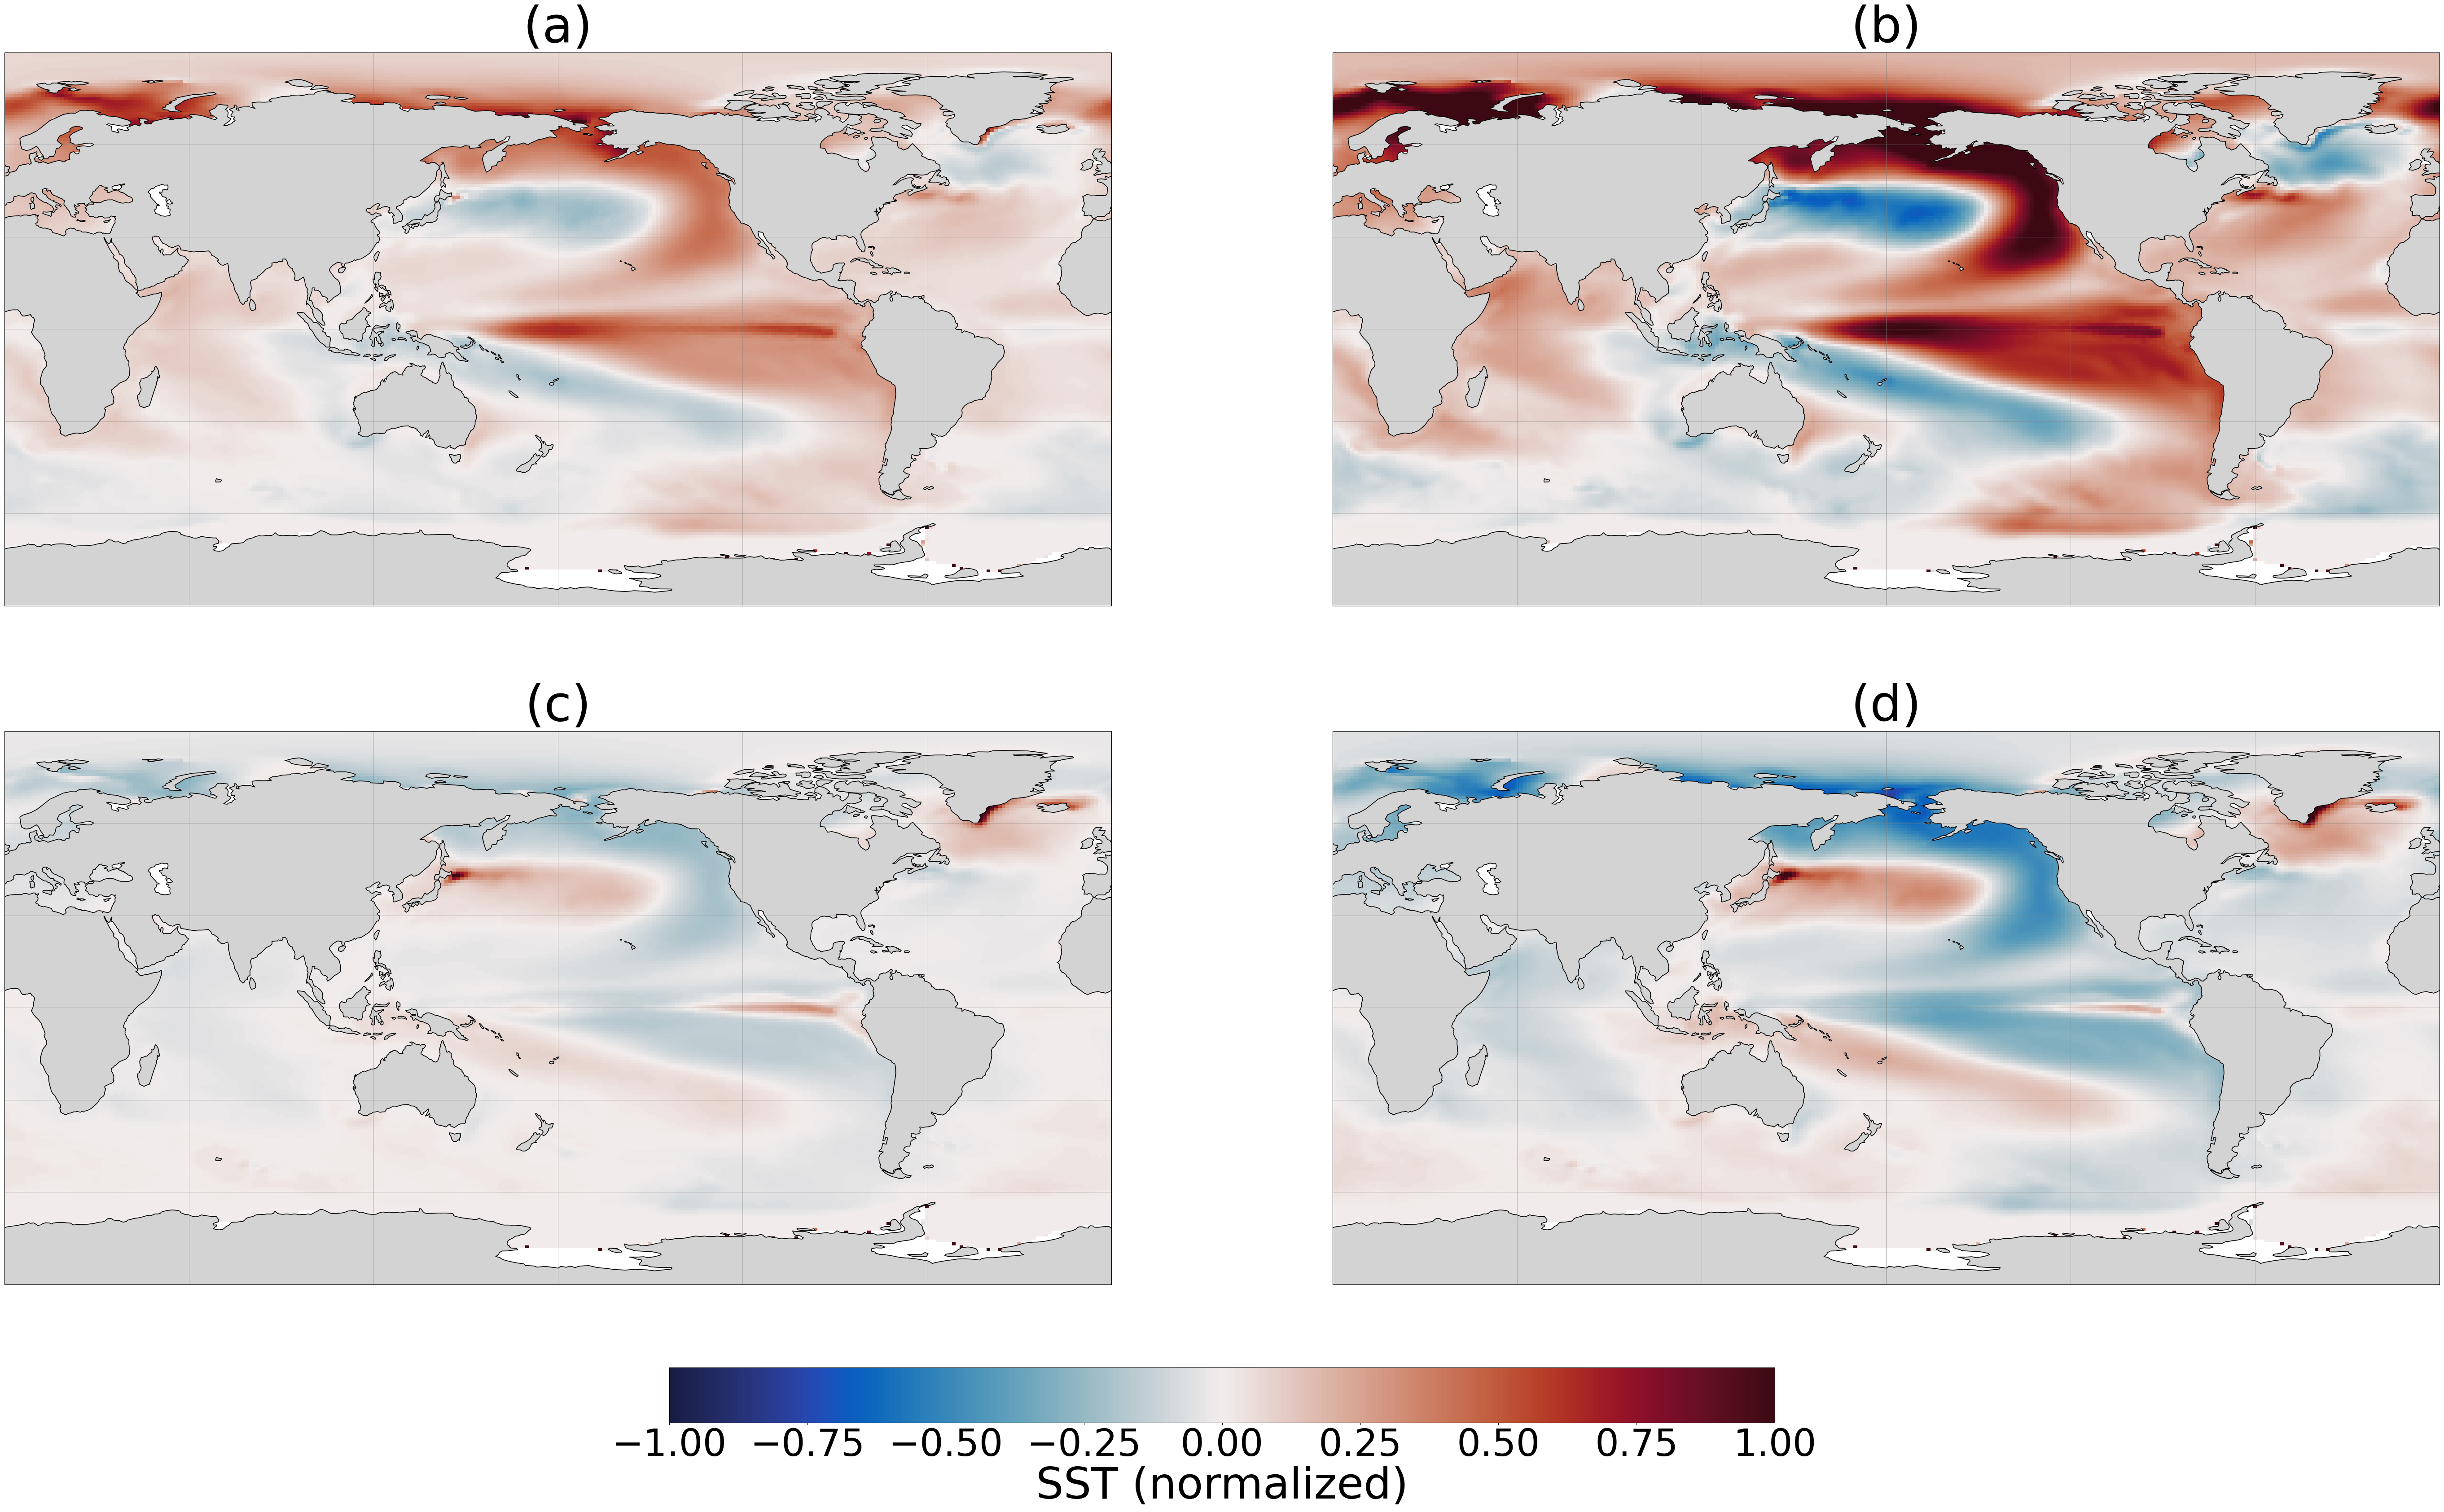

In [11]:
plt.rcParams.update({
    'font.size': 14*5,
    'axes.titlesize': 16*5,
    'axes.labelsize': 14*5,
    'xtick.labelsize': 12*5,
    'ytick.labelsize': 12*5,
    'legend.fontsize': 12*5,
})
# ── Figure (publication-ready version) ────────────────────────────────────────
lon2d, lat2d = np.meshgrid(lon_plot, lat_plot)
proj = ccrs.PlateCarree(central_longitude=180)

fig, axes = plt.subplots(
    2, 2, figsize=(14*5, 8*5), subplot_kw={'projection': proj}
)

panels = [
    (axes[0, 0], grand['ALL_SLOW'],    '(a)'),
    (axes[0, 1], grand['TP'],          '(b)'),
    (axes[1, 0], grand['ALL_NONSLOW'], '(c)'),
    (axes[1, 1], grand['TN'],          '(d)'),
]

for ax, data, title in panels:
    ax.set_global()
    ax.add_feature(cfeature.LAND, facecolor='lightgray', zorder=1)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.6*2, zorder=2)
    ax.gridlines(draw_labels=False, linewidth=0.3*2, color='gray', alpha=0.5)

    im = ax.pcolormesh(
        lon2d, lat2d, data,
        cmap=cmocean.cm.balance,
        vmin=-1, vmax=1,
        transform=ccrs.PlateCarree(),
        shading='auto',
        zorder=0,
    )
    ax.set_title(title)

# Shared horizontal colorbar
cbar = fig.colorbar(
    im, ax=axes.ravel().tolist(), orientation='horizontal',
    fraction=0.04, pad=0.06, shrink=0.7,
)
cbar.set_label('SST (normalized)')

plt.show()
